## Simulating `my_ml_lib` Structure

To achieve the requested modularity within the Colab environment, I will simulate the creation of `metrics.py` and `linear_models.py` by placing their respective contents into separate code cells. Think of the following cells as the content of those files.

First, the content for `metrics.py`:

In [ ]:
import numpy as np

def mean_squared_error(y_true, y_pred):
    """
    Calculates the Mean Squared Error (MSE).
    MSE measures the average of the squares of the errors.
    """
    if len(y_true.shape) == 1:
        y_true = y_true.reshape(-1, 1)
    if len(y_pred.shape) == 1:
        y_pred = y_pred.reshape(-1, 1)

    return np.mean((y_true - y_pred) ** 2)

def r2_score(y_true, y_pred):
    """
    Calculates the R^2 (coefficient of determination) regression score function.
    Best possible score is 1.0.
    """
    if len(y_true.shape) == 1:
        y_true = y_true.reshape(-1, 1)
    if len(y_pred.shape) == 1:
        y_pred = y_pred.reshape(-1, 1)

    residual_sum_of_squares = ((y_true - y_pred) ** 2).sum()
    total_sum_of_squares = ((y_true - y_true.mean()) ** 2).sum()

    # Handle edge case where total_sum_of_squares is 0
    if total_sum_of_squares == 0:
        return 0.0

    return 1 - (residual_sum_of_squares / total_sum_of_squares)

Next, the updated content for `linear_models.py`, which includes the modified `LinearRegression` (without its `score` method), `SGDRegressor`, and `Ridge` classes:

In [ ]:
import numpy as np

class LinearRegression:
    """
    Custom Ordinary Least Squares (OLS) Linear Regression model
    using the Normal Equation.
    """
    def __init__(self):
        self.weights = None
        self.bias = None

    def fit(self, X, y):
        """
        Fit the linear model.

        Parameters:
        X : numpy array of shape (n_samples, n_features)
            Training data
        y : numpy array of shape (n_samples,) or (n_samples, 1)
            Target values

        Returns:
        self : returns an instance of self.
        """
        # Ensure y is a column vector
        if len(y.shape) == 1:
            y = y.reshape(-1, 1)

        # 1. Add a column of ones to X for the bias (intercept) term
        n_samples = X.shape[0]
        X_b = np.c_[np.ones((n_samples, 1)), X]

        # 2. Normal Equation: theta = (X^T * X)^-1 * X^T * y
        # We use np.linalg.pinv (pseudo-inverse) instead of inv.
        # It is safer and handles edge cases where the matrix might be singular.
        theta_best = np.linalg.pinv(X_b.T.dot(X_b)).dot(X_b.T).dot(y)

        # 3. Extract bias (intercept) and weights (coefficients)
        self.bias = theta_best[0]
        self.weights = theta_best[1:]

        return self

    def predict(self, X):
        """
        Predict using the linear model.

        Parameters:
        X : numpy array of shape (n_samples, n_features)
            Samples to predict

        Returns:
        y_pred : numpy array of predicted values
        """
        if self.weights is None or self.bias is None:
            raise ValueError("Model is not fitted yet. Call 'fit' first.")

        return X.dot(self.weights) + self.bias

    @property
    def coef_(self):
        return self.weights.flatten() if self.weights is not None else None

    @property
    def intercept_(self):
        return self.bias.item() if self.bias is not None else None


class SGDRegressor:
    """
    Linear model fitted by minimizing a regularized empirical loss with Gradient Descent.
    (Implemented here using Batch Gradient Descent for vectorized speed).
    """
    def __init__(self, learning_rate=0.01, epochs=1000):
        self.learning_rate = learning_rate
        self.epochs = epochs
        self.weights = None
        self.bias = np.array([0.0]) # Initialize bias as a 1-element NumPy array here

    def fit(self, X, y):
        n_samples, n_features = X.shape

        self.weights = np.zeros((n_features, 1))

        if len(y.shape) == 1:
            y = y.reshape(-1, 1)

        # Gradient Descent loop
        for _ in range(self.epochs):
            # 1. Calculate predictions with current weights
            y_pred = X.dot(self.weights) + self.bias

            # 2. Calculate gradients
            dw = (2 / n_samples) * X.T.dot(y_pred - y)
            db = (2 / n_samples) * np.sum(y_pred - y) # db is a scalar float

            # 3. Update parameters
            self.weights -= self.learning_rate * dw
            # Explicitly update the single element of the bias array
            self.bias[0] -= self.learning_rate * db

        return self

    def predict(self, X):
        if self.weights is None:
            raise ValueError("Model is not fitted yet.")
        return X.dot(self.weights) + self.bias

    @property
    def coef_(self):
        return self.weights.flatten() if self.weights is not None else None

    @property
    def intercept_(self):
        return self.bias.item() if self.bias is not None else None


class Ridge:
    """
    Linear least squares with L2 regularization.
    Minimizes the objective function: ||y - Xw||^2_2 + alpha * ||w||^2_2
    """
    def __init__(self, alpha=1.0):
        self.alpha = alpha  # Regularization strength
        self.weights = None
        self.bias = None

    def fit(self, X, y):
        if len(y.shape) == 1:
            y = y.reshape(-1, 1)

        n_samples, n_features = X.shape
        X_b = np.c_[np.ones((n_samples, 1)), X]

        # Identity matrix for the penalty term
        # Size is n_features + 1 to account for the bias column
        A = np.eye(n_features + 1)

        # We do NOT regularize the bias term (the intercept)
        A[0, 0] = 0

        # Regularized Normal Equation: theta = (X^T * X + alpha * A)^-1 * X^T * y
        theta_best = np.linalg.pinv(X_b.T.dot(X_b) + self.alpha * A).dot(X_b.T).dot(y)

        self.bias = theta_best[0]
        self.weights = theta_best[1:]

        return self

    def predict(self, X):
        if self.weights is None or self.bias is None:
            raise ValueError("Model is not fitted yet.")
        return X.dot(self.weights) + self.bias

    @property
    def coef_(self):
        return self.weights.flatten() if self.weights is not None else None

    @property
    def intercept_(self):
        return self.bias.item() if self.bias is not None else None

Finally, here is the testing script that uses the new `LinearRegression`, `SGDRegressor`, and `Ridge` classes, along with the `mean_squared_error` and `r2_score` functions. In a real project, this would be a separate script that imports from your `my_ml_lib` package.

In [ ]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score # Import from current environment/my_ml_lib

# --- 1. Generate Synthetic Data ---
# Consistent random state for reproducibility
np.random.seed(42)

n_samples = 200
n_features = 2

# True underlying parameters for a linear relationship
true_weights = np.array([[3.0], [1.5]])
true_bias = 4

# Generate features (X)
X = np.random.rand(n_samples, n_features) * 2 # Features between 0 and 2

# Generate target (y) with some noise
noise = np.random.randn(n_samples, 1) * 0.5
predictions = X.dot(true_weights) + true_bias
y = predictions + noise

# --- 2. Split Data into Training and Testing Sets ---
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_test shape: {y_test.shape}")

# --- 3. Instantiate and Fit Models ---
# Create instances of our custom models
ols_model = LinearRegression()
sgd_model = SGDRegressor(learning_rate=0.01, epochs=1000)
ridge_model = Ridge(alpha=1.0)

# Fit the models on the training data
print("\nFitting OLS (Normal Equation) model...")
ols_model.fit(X_train, y_train)

print("Fitting SGD Regressor model...")
sgd_model.fit(X_train, y_train)

print("Fitting Ridge Regressor (L2) model...")
ridge_model.fit(X_train, y_train)

# Store models in a dictionary for easy access later
models = {
    'OLS (Normal Equation)': ols_model,
    'SGD Regressor': sgd_model,
    'Ridge Regressor (L2)': ridge_model
}

print("\nModels fitted successfully!")

X_train shape: (160, 2)
y_train shape: (160, 1)
X_test shape: (40, 2)
y_test shape: (40, 1)

Fitting OLS (Normal Equation) model...
Fitting SGD Regressor model...
Fitting Ridge Regressor (L2) model...

Models fitted successfully!


In [ ]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score # Import from current environment/my_ml_lib

# --- 1. Generate Synthetic Data ---
# Consistent random state for reproducibility
np.random.seed(42)

n_samples = 200
n_features = 2

# True underlying parameters for a linear relationship
true_weights = np.array([[3.0], [1.5]])
true_bias = 4

# Generate features (X)
X = np.random.rand(n_samples, n_features) * 2 # Features between 0 and 2

# Generate target (y) with some noise
noise = np.random.randn(n_samples, 1) * 0.5
predictions = X.dot(true_weights) + true_bias
y = predictions + noise

# --- 2. Split Data into Training and Testing Sets ---
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_test shape: {y_test.shape}")

# --- 3. Instantiate and Fit Models ---
# Create instances of our custom models
ols_model = LinearRegression()
sgd_model = SGDRegressor(learning_rate=0.01, epochs=1000)
ridge_model = Ridge(alpha=1.0)

# Fit the models on the training data
print("\nFitting OLS (Normal Equation) model...")
ols_model.fit(X_train, y_train)

print("Fitting SGD Regressor model...")
sgd_model.fit(X_train, y_train)

print("Fitting Ridge Regressor (L2) model...")
ridge_model.fit(X_train, y_train)

# Store models in a dictionary for easy access later
models = {
    'OLS (Normal Equation)': ols_model,
    'SGD Regressor': sgd_model,
    'Ridge Regressor (L2)': ridge_model
}

print("\nModels fitted successfully!")


X_train shape: (160, 2)
y_train shape: (160, 1)
X_test shape: (40, 2)
y_test shape: (40, 1)

Fitting OLS (Normal Equation) model...
Fitting SGD Regressor model...
Fitting Ridge Regressor (L2) model...

Models fitted successfully!


## Inspecting Intercepts and Coefficients

In [ ]:
print("### Intercepts and Coefficients of Fitted Models ###")

for name, model in models.items():
    print(f"\n--- {name} ---")
    try:
        print(f"Intercept: {model.intercept_}")
        print(f"Coefficients: {model.coef_}")
    except AttributeError:
        print("Intercept and Coefficients not available or model not fitted.")

### Intercepts and Coefficients of Fitted Models ###

--- OLS (Normal Equation) ---
Intercept: 3.9977185658801897
Coefficients: [3.02669502 1.48983228]

--- SGD Regressor ---
Intercept: 3.85532524355909
Coefficients: [3.0897143  1.55542278]

--- Ridge Regressor (L2) ---
Intercept: 4.073190962394353
Coefficients: [2.97504715 1.46534218]


## Feature Selection with Forward Selection based on Correlation

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

def forward_selection(X, y, model_class, features_names, threshold=0.01):
    """
    Performs forward feature selection based on correlation and model performance.
    It starts with no features and adds the one that gives the best improvement
    until no significant improvement is found.
    """
    selected_features = []
    remaining_features = list(range(X.shape[1]))
    best_r2 = -float('inf')
    history = []

    while remaining_features:
        best_new_feature = None
        current_best_r2_improvement = 0

        # Temporarily store performance for this iteration to pick the best
        iteration_performances = {}

        for feature_idx in remaining_features:
            current_selection = selected_features + [feature_idx]

            # Ensure current_selection is sorted for consistent column indexing if needed
            current_selection_sorted = sorted(current_selection)

            X_selected = X[:, current_selection_sorted]

            # Split data for this feature set
            X_train_fs, X_test_fs, y_train_fs, y_test_fs = train_test_split(X_selected, y, test_size=0.2, random_state=42)

            model = model_class()
            model.fit(X_train_fs, y_train_fs)
            y_pred_fs = model.predict(X_test_fs)
            r2 = r2_score(y_test_fs, y_pred_fs)

            iteration_performances[feature_idx] = r2

            if r2 > best_r2:
                # This is a potential improvement over the overall best R2 found so far
                improvement = r2 - best_r2
                if improvement > threshold: # Only consider significant improvements
                    current_best_r2_improvement = improvement
                    best_new_feature = feature_idx

        if best_new_feature is not None:
            selected_features.append(best_new_feature)
            remaining_features.remove(best_new_feature)
            best_r2 = iteration_performances[best_new_feature] # Update overall best R2
            history.append((features_names[best_new_feature], best_r2))
            print(f"Added feature '{features_names[best_new_feature]}' with R2: {best_r2:.4f}")
        else:
            break # No significant improvement found

    return selected_features, history

# Assuming X has been generated from a DataFrame or we need to create feature names
# Let's create dummy feature names if not available.
# In a real scenario, these would come from your dataset.

# Create a DataFrame for correlation calculation and to get feature names easily
# Assuming X has 2 features based on the context (true_weights has 2 elements)
feature_names = [f'Feature_{i+1}' for i in range(X.shape[1])]
df_features = pd.DataFrame(X, columns=feature_names)
df_features['target'] = y

print("\n--- Running Forward Feature Selection with LinearRegression ---")
selected_feature_indices, selection_history = forward_selection(X, y, LinearRegression, feature_names)

print("\nSelected Features:")
final_selected_features = [feature_names[i] for i in selected_feature_indices]
print(final_selected_features)
print("Selection History:")
for feature, r2 in selection_history:
    print(f" - Added {feature}: R2 = {r2:.4f}")


--- Running Forward Feature Selection with LinearRegression ---
Added feature 'Feature_2' with R2: 0.1644
Added feature 'Feature_1' with R2: 0.9106

Selected Features:
['Feature_2', 'Feature_1']
Selection History:
 - Added Feature_2: R2 = 0.1644
 - Added Feature_1: R2 = 0.9106


## Correlation Map

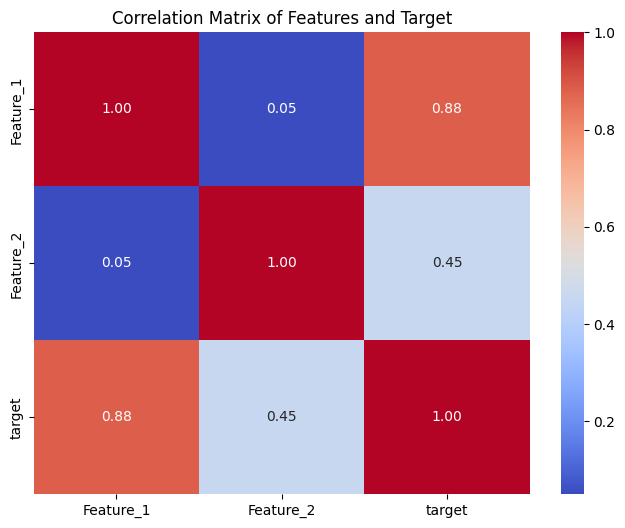

In [ ]:
plt.figure(figsize=(8, 6))
sns.heatmap(df_features.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Features and Target')
plt.show()

## Actual vs. Predicted Values Plot

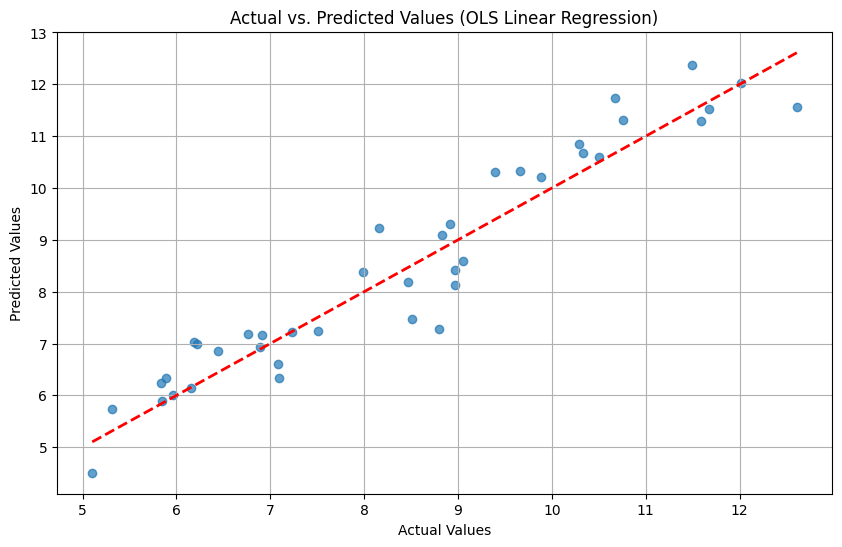

In [ ]:
import matplotlib.pyplot as plt

# We'll use the LinearRegression model for this visualization
# as it's the most straightforward to interpret.
linear_model = models['OLS (Normal Equation)']
y_pred_ols = linear_model.predict(X_test)

plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred_ols, alpha=0.7)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('Actual vs. Predicted Values (OLS Linear Regression)')
plt.grid(True)
plt.show()
